<a href="https://colab.research.google.com/github/einar6969/st-gr4/blob/main/Forritunarverkefni_24_copy_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.sparse.linalg import spsolve

In [ ]:
def Helmholtzeq(L1, L2, h, k, lam, w0, v0):
    # Skilgreina fjölda skiptinga á hvorum ás
    M = int(L1 / h)
    N = int(L2 / k)

    # Skilgreina stærð punktanets
    P = (M + 1) * (N + 1)

    # Búa til tómt fylki A og vigur b
    A = lil_matrix((P, P))
    b = np.zeros(P)

    # Fall til að varpa 2D netkoordinötum yfir í 1D fylkisvísi
    def idx(i, j):
        return j * (M + 1) + i

    # Fylla út í A fylkið og b vigurinn
    for j in range(N + 1):
        for i in range(M + 1):
            index = idx(i, j)
            if j == 0:  # Jaðarskilyrði á efri mörk
                A[index, index] = 1
                b[index] = w0  # w(x) = w0 fyrir 0 ≤ x ≤ L1
            elif j == N:  # Jaðarskilyrði á neðri mörk
                A[index, index] = 1
                b[index] = v0  # v(x) = v0 fyrir 0 ≤ x ≤ L1
            else:
                if i == 0 or i == M:  # Neumann jaðarskilyrði á hliðum
                    if i == 0:
                        A[index, index] = -1 / h
                        A[index, index + 1] = 1 / h
                    else:
                        A[index, index] = 1 / h
                        A[index, index - 1] = -1 / h
                else:
                    A[index, index] = -2 / h**2 - 2 / k**2 - lam**2
                    A[index, index - 1] = 1 / h**2
                    A[index, index + 1] = 1 / h**2
                    A[index, idx(i, j - 1)] = 1 / k**2
                    A[index, idx(i, j + 1)] = 1 / k**2

    # Breyta A yfir í CSR snið fyrir skilvirkari lausn
    A_csr = A.tocsr()

    # Leysa jöfnuhneppið
    c = spsolve(A_csr, b)

    HZ = c.reshape((N + 1, M + 1))

    return HZ


L1 = L2 = 1
h = 1 / 5
k = 1 / 6
lam = 1 / 2
w0 = 1
v0 = 5

HZ = Helmholtzeq(L1, L2, h, k, lam, w0, v0)
print("Reiknað HZ Fylki:")
print(HZ)

Reiknað HZ Fylki:
[[1.         1.         1.         1.         1.         1.        ]
 [1.62348392 1.62348392 1.62348392 1.62348392 1.62348392 1.62348392]
 [2.25824203 2.25824203 2.25824203 2.25824203 2.25824203 2.25824203]
 [2.90868237 2.90868237 2.90868237 2.90868237 2.90868237 2.90868237]
 [3.5793219  3.5793219  3.5793219  3.5793219  3.5793219  3.5793219 ]
 [4.27481783 4.27481783 4.27481783 4.27481783 4.27481783 4.27481783]
 [5.         5.         5.         5.         5.         5.        ]]


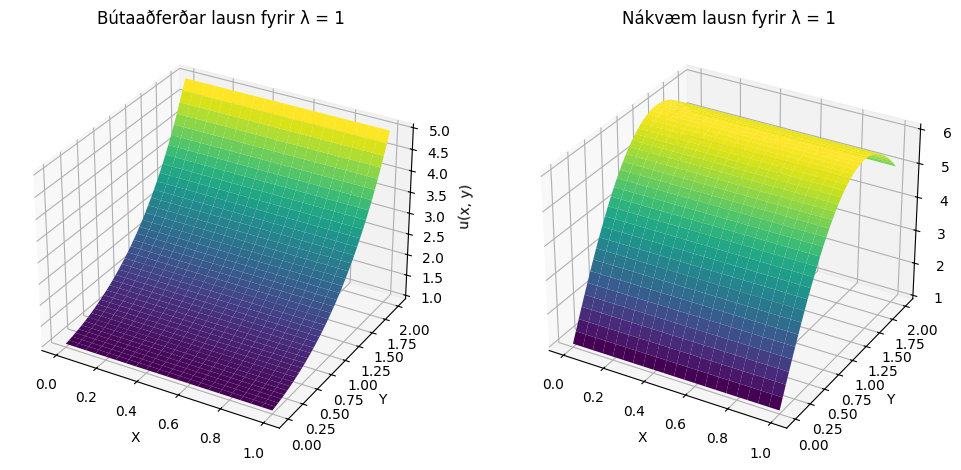

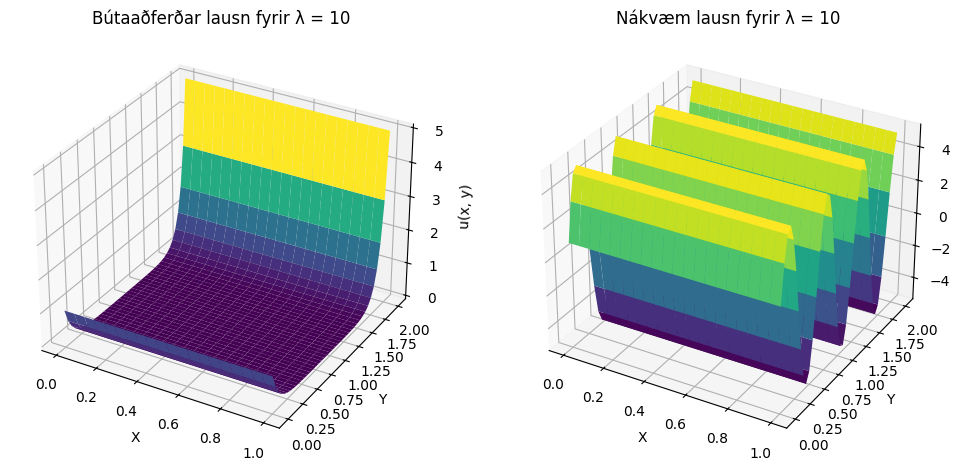

In [ ]:
def Helmholtzeq(L1, L2, h, k, lam, w0, v0):
    # Skilgreina fjölda skiptinga á hvorum ás
    M = int(L1 / h)
    N = int(L2 / k)

    # Skilgreina stærð punktanets
    P = (M + 1) * (N + 1)

    # Búa til tómt fylki A og vigur b
    A = lil_matrix((P, P))
    b = np.zeros(P)

    # Fall til að varpa 2D netkoordinötum yfir í 1D fylkisvísi
    def idx(i, j):
        return j * (M + 1) + i

    # Fylla út í A fylkið og b vigurinn
    for j in range(N + 1):
        for i in range(M + 1):
            index = idx(i, j)
            if j == 0:  # Jaðarskilyrði á efri mörk
                A[index, index] = 1
                b[index] = w0  # w(x) = w0 fyrir 0 ≤ x ≤ L1
            elif j == N:  # Jaðarskilyrði á neðri mörk
                A[index, index] = 1
                b[index] = v0  # v(x) = v0 fyrir 0 ≤ x ≤ L1
            else:
                if i == 0 or i == M:  # Neumann jaðarskilyrði á hliðum
                    if i == 0:
                        A[index, index] = -1 / h
                        A[index, index + 1] = 1 / h
                    else:
                        A[index, index] = 1 / h
                        A[index, index - 1] = -1 / h
                else:
                    A[index, index] = -2 / h**2 - 2 / k**2 - lam**2
                    A[index, index - 1] = 1 / h**2
                    A[index, index + 1] = 1 / h**2
                    A[index, idx(i, j - 1)] = 1 / k**2
                    A[index, idx(i, j + 1)] = 1 / k**2

    # Breyta A yfir í CSR snið fyrir skilvirkari lausn
    A_csr = A.tocsr()

    # Leysa jöfnuhneppið
    c = spsolve(A_csr, b)

    HZ = c.reshape((N + 1, M + 1))

    return HZ

def bein_lausn(x, y, λ, L2, w0, v0):
    part1 = (((v0 - w0 * np.cos(λ * L2)) / np.sin(λ * L2)**2) * np.cos(λ * (L2 - y)))
    part2 = (((w0 - v0 * np.cos(λ * L2)) / np.sin(λ * L2)**2) * np.cos(λ * y))
    return part1 + part2

# Fastar
L1 = 1.0
L2 = 2.0
h = k = 1/20
w0 = 1
v0 = 5
λ_values = [1, 10]

for λ in λ_values:
    HZ = Helmholtzeq(L1, L2, h, k, λ, w0, v0)
    X, Y = np.meshgrid(np.linspace(0, L1, int(L1 / h) + 1), np.linspace(0, L2, int(L2 / k) + 1))
    Ue = bein_lausn(X, Y, λ, L2, w0, v0)

    # Plotta bútaaðferðar lausn
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(121, projection='3d')
    ax.plot_surface(X, Y, HZ, cmap='viridis')
    ax.set_title(f'Bútaaðferðar lausn fyrir λ = {λ}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('u(x, y)')

    # Plotta beina lausn
    ax = fig.add_subplot(122, projection='3d')
    ax.plot_surface(X, Y, Ue, cmap='viridis')
    ax.set_title(f'Nákvæm lausn fyrir λ = {λ}')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('u(x, y)')

    plt.show()

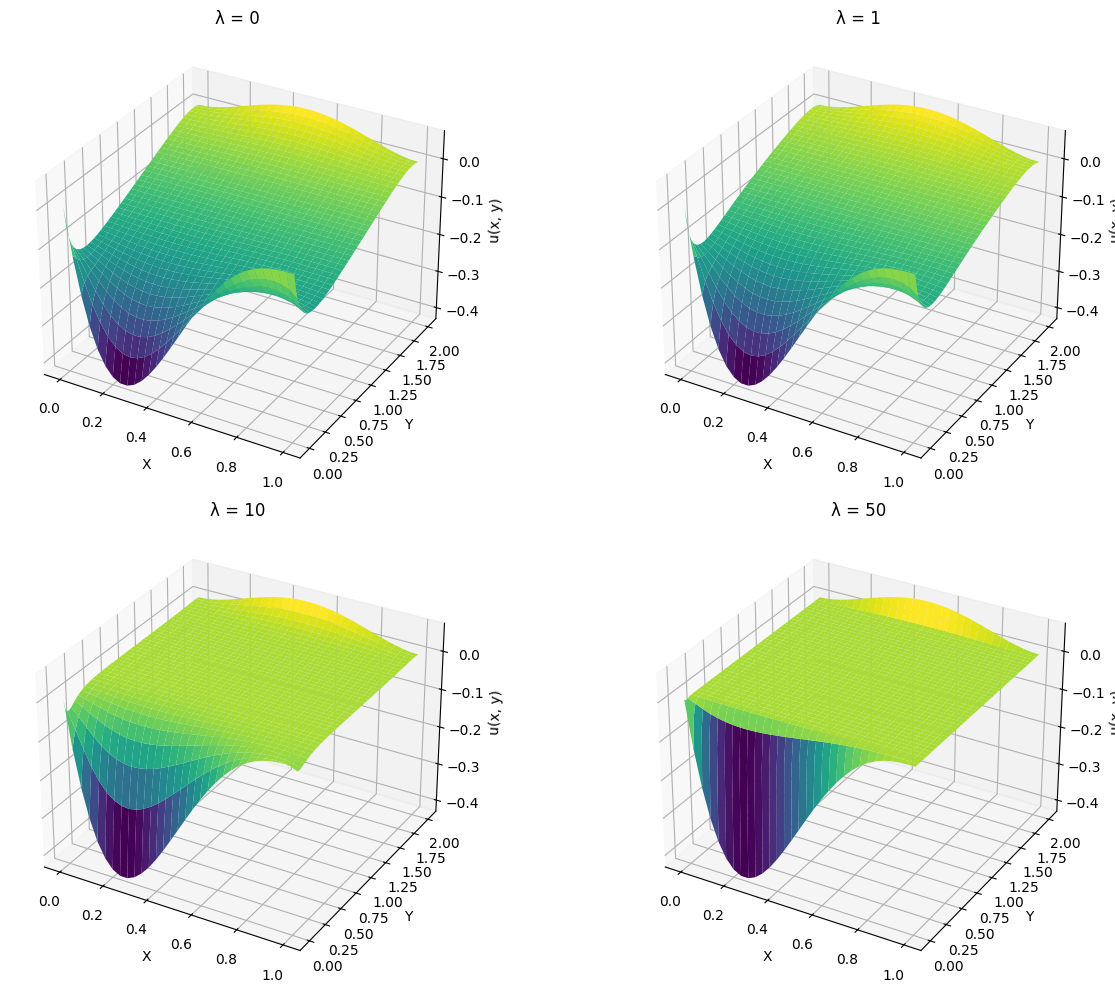

In [ ]:
def Helmholtzeq(L1, L2, h, k, λ, w0, v0):
    N = int(L1 / h)
    M = int(L2 / k)
    P = (N + 1) * (M + 1)

    A = lil_matrix((P, P))
    b = np.zeros(P)

    def w(x, L1):
        return 4 * x * (x - L1)**3

    def v(x, L1):
        return x**2 * (x - L1)**2

    def index(i, j):
        return j * (N + 1) + i

    for j in range(M + 1):
        for i in range(N + 1):
            idx = index(i, j)
            x_pos = i * h
            if j == 0:
                A[idx, idx] = 1
                b[idx] = w(x_pos, L1)
            elif j == M:
                A[idx, idx] = 1
                b[idx] = v(x_pos, L1)
            else:
                A[idx, idx] = -2 / h**2 - 2 / k**2 - λ**2
                A[idx, index(i + 1, j)] = 1 / h**2
                A[idx, index(i - 1, j)] = 1 / h**2
                A[idx, index(i, j + 1)] = 1 / k**2
                A[idx, index(i, j - 1)] = 1 / k**2

    c = spsolve(A.tocsr(), b)
    HZ = np.zeros((M + 1, N + 1))
    for j in range(M + 1):
        for i in range(N + 1):
            HZ[j, i] = c[index(i, j)]

    return HZ

# Gildi fastanna
L1, L2 = 1, 2
h, k = 1/30, 1/40
λ_values = [0, 1, 10, 50]

# Plotta fyrir hvert λ
fig, axes = plt.subplots(2, 2, subplot_kw={'projection': '3d'}, figsize=(14, 10))
axes = axes.flatten()

for i, λ in enumerate(λ_values):
    HZ = Helmholtzeq(L1, L2, h, k, λ, 1, 5)
    X, Y = np.meshgrid(np.linspace(0, L1, int(L1 / h) + 1), np.linspace(0, L2, int(L2 / k) + 1))
    axes[i].plot_surface(X, Y, HZ, cmap='viridis')
    axes[i].set_title(f'λ = {λ}')
    axes[i].set_xlabel('X')
    axes[i].set_ylabel('Y')
    axes[i].set_zlabel('u(x, y)')

plt.tight_layout()
plt.show()
